**Previously on:** Lecture 22 fit a genuinely nonlinear model to one input, one output.
Today's models are back to being linear in their parameters -- the new twist is *how many
inputs* feed the line at once.

Today's topics:
* `x` as a table, not a column -- multiple features predicting one target
* reading a coefficient: "effect per unit change, holding everything else fixed"
* why raw coefficient size can lie to you, and the standardization fix
* evaluating a multivariate model with the same train/test habits as Lecture 20

> By the end of today you should be able to complete HW8's multivariate-fit problems: fit
> a model with several predictors and read each coefficient as a per-feature sensitivity.

# From one input to many

Lecture 19 predicted tensile strength from one number, proof stress. But a 3D-printed
part's quality depends on *seven* dials set on the printer at once -- layer height, wall
thickness, infill density, nozzle and bed temperature, print speed, fan speed. Nobody
changes just one at a time. If a part keeps failing tension tests, which knob would you
turn? Today's model is how you find out.

## Dataset: 3D Printing (FDM) Parameters

Data come from [this github repository](https://github.com/ahmetokudan/3dprinterdeeplearning)
and are provided with an unlimited license (public domain).

In [1]:
import os
import pandas as pd

_file = '3dprinting.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e
data.head()  # show a view of the data file

,layer_height (mm),wall_thickness (mm),infill_density (%),infill_pattern,nozzle_temperature (degC),bed_temperature (degC),print_velocity (mm/s),material,fan_speed (%),roughness (microns),tension_strength (Mpa),elongation (%)
0,0.02,8,90,grid,220,60,40,abs,0,25,18,1.2
1,0.02,7,90,honeycomb,225,65,40,abs,25,32,16,1.4
2,0.02,1,80,grid,230,70,40,abs,50,40,8,0.8
3,0.02,4,70,honeycomb,240,75,40,abs,75,68,10,0.5
4,0.02,6,90,grid,250,80,40,abs,100,92,5,0.7


`x` is now a **DataFrame** -- every row is one printed part, every column one setting or
measurement:

In [2]:
features = ['layer_height (mm)', 'wall_thickness (mm)', 'infill_density (%)',
            'nozzle_temperature (degC)', 'bed_temperature (degC)',
            'print_velocity (mm/s)', 'fan_speed (%)']
x = data[features]
y = data['tension_strength (Mpa)']
print(x.shape, y.shape)
x.head()

(50, 7) (50,)


,layer_height (mm),wall_thickness (mm),infill_density (%),nozzle_temperature (degC),bed_temperature (degC),print_velocity (mm/s),fan_speed (%)
0,0.02,8,90,220,60,40,0
1,0.02,7,90,225,65,40,25
2,0.02,1,80,230,70,40,50
3,0.02,4,70,240,75,40,75
4,0.02,6,90,250,80,40,100


Two columns, `infill_pattern` and `material`, are quietly left out: they're text
categories, and a linear model can't multiply a coefficient by the word `'honeycomb'`.
There's a trick for that (one-hot encoding) -- not today's topic, just flagged as a thing
that exists.

# Fitting the multivariate model

Same `.predict()`-wrapped least-squares fit from Lecture 20's evaluation toolkit -- the
only change is `x` now has 7 columns instead of 1:

In [3]:
import numpy as np


class LinearModel:
    "Wraps lstsq-fitted coefficients with a .predict() method, same shape as Lecture 20."

    def __init__(self, coeffs):
        self.coeffs = coeffs

    def predict(self, x):
        X = np.column_stack([np.ones(len(x)), np.asarray(x)])
        return X.dot(self.coeffs)


def fit_linear(x, y):
    "Least-squares fit with an intercept column, via np.linalg.lstsq."
    X = np.column_stack([np.ones(len(x)), np.asarray(x)])
    coeffs, *_ = np.linalg.lstsq(X, np.asarray(y), rcond=None)
    return LinearModel(coeffs)


model = fit_linear(x, y)
y_pred = model.predict(x)
sse = np.sum((y.to_numpy() - y_pred) ** 2)
sst = np.sum((y.to_numpy() - y.mean()) ** 2)
print('intercept:', model.coeffs[0])
for name, c in zip(features, model.coeffs[1:]):
    print(f'{name:28s} {c: .4f}')
print('R2:', 1 - sse / sst)

intercept: 0.019617661137455868
layer_height (mm)             55.6460
wall_thickness (mm)           1.0743
infill_density (%)            0.1537
nozzle_temperature (degC)    -0.3047
bed_temperature (degC)        1.1348
print_velocity (mm/s)        -0.0161
fan_speed (%)                -0.2114
R2: 0.63675238625633


`tension_strength ≈ b0 + b1*layer_height + b2*wall_thickness + ... + b7*fan_speed` -- the
same "line" idea as Lecture 19, just seven slopes instead of one. R² ≈ 0.64, and
`layer_height`'s coefficient (≈55.6) towers over the rest -- hold that thought.

# Reading a coefficient: "holding everything else fixed"

In one-feature regression, slope meant "change in y per unit change in x." With several
features, each coefficient means the same thing **but only if every other feature stays
put**:
* `wall_thickness` ≈ +1.07: thicker walls, all else equal, means modestly stronger parts
  -- physically sensible, more solid material bearing the load.
* `nozzle_temperature` ≈ -0.30: a hotter nozzle *lowers* predicted strength, all else
  equal. The model doesn't know why -- only that -- but over-extrusion or degradation at
  high temperature is a plausible physical story.
* `print_velocity` ≈ -0.016: tiny. Does that mean print speed barely matters? Hold that
  thought -- Section 4 is about to complicate it.

A coefficient answers "what happens if I nudge *this* setting and freeze the rest" -- it
does **not** say what happens if several knobs move together, and it does not by itself
say which knob matters *most*.

# Why "biggest coefficient" can lie to you

`layer_height`'s coefficient is 50x `wall_thickness`'s. Does layer height matter 50x more?
Check the units first:

In [4]:
x.agg(['min', 'max', 'std']).T

,min,max,std
layer_height (mm),0.02,0.2,0.064397
wall_thickness (mm),1.00,10.0,2.922747
infill_density (%),10.00,90.0,25.363480
nozzle_temperature (degC),200.00,250.0,14.820353
bed_temperature (degC),60.00,80.0,7.142857
print_velocity (mm/s),40.00,120.0,29.692300
fan_speed (%),0.00,100.0,35.714286


`layer_height` spans only 0.02-0.2 mm (std ≈ 0.06) while `fan_speed` spans 0-100% (std ≈
35.7). A "1-unit change" in layer height is most of its entire observed range; a "1-unit
change" in fan speed is a rounding error. `layer_height`'s huge coefficient is large
*because the units are tiny*, not necessarily because the effect is large.

Fix: rescale every feature to mean 0, std 1 -- the same z-score you wrote in Lecture 14's
check-your-understanding (`zscore(x, value)`), `(x - mean) / std`, applied per column -- so
"1 unit" means "1 standard deviation" everywhere:

In [5]:
x_scaled = (x - x.mean()) / x.std()
model_scaled = fit_linear(x_scaled, y)
y_pred_scaled = model_scaled.predict(x_scaled)
r2_scaled = 1 - np.sum((y.to_numpy() - y_pred_scaled) ** 2) / sst
for name, c in zip(features, model_scaled.coeffs[1:]):
    print(f'{name:28s} {c: .3f}')
print('R2:', r2_scaled)

layer_height (mm)             3.583
wall_thickness (mm)           3.140
infill_density (%)            3.897
nozzle_temperature (degC)    -4.515
bed_temperature (degC)        0.278
print_velocity (mm/s)        -0.478
fan_speed (%)                 0.278
R2: 0.6367523862563299


R² is identical, 0.64 = 0.64 -- scaling doesn't change what the model predicts, only how
to *read* the coefficients. On a fair footing, `nozzle_temperature` (≈ -4.5) is now the
largest-magnitude coefficient, then `infill_density` (≈ 3.9), `layer_height` (≈ 3.6), and
`wall_thickness` (≈ 3.1) -- `layer_height`'s raw-fit dominance was a units artifact.

One more wrinkle, worth naming rather than hiding: `bed_temperature` and `fan_speed` come
out tied at ≈ 0.28 -- and that tie is not a coincidence. This printer's operator changed
them together on every run (`data[['bed_temperature (degC)', 'fan_speed (%)']].corr()`
reports exactly 1.0). When two features move in lockstep, the data cannot tell their
individual effects apart -- the fit can split credit between them in more than one
equally-valid way, and a different least-squares solver could report a different split
with the identical R². Lecture 38 (design of experiments) is built entirely around this
failure mode: an experiment that never varies two settings independently can never
separate their effects, no matter how the fitting is done.

# Evaluating honestly: train/test, revisited

Quick callback to Lecture 20's habit, applied to the new multivariate model. With 7
features there is no line left to draw over a scatter -- so this is also the moment to
say that out loud: we can't draw the fit anymore, but we can still score it.

## Train/Test Split

In order to evaluate the performance of a model on unseen data, we need
to *hold out* some data. This will be called the **test** data.
The data used to fit will be called the **training** data.

As we use more sophisticated models, it is vitally important that we
evaluate our models in this way to avoid *overfitting*.
Remember that a model with enough degrees of freedom can perfectly fit
any data, but it won't have any predictive power!

```
all data:    [########################################################]
shuffle, then slice into two pieces:
train (75%): [##########################################]
test  (25%):                                              [##########]
```

We shuffle the *indices* once, then slice both `x` and `y` with that same shuffled order --
so a row's features and its target always stay paired.

In [6]:
import numpy as np

# split indices rather than data -- more flexible
rng = np.random.default_rng(0)
shuffled = rng.permutation(data.index)
n_test = int(np.ceil(0.25 * len(shuffled)))
idx_test = shuffled[:n_test]
idx_train = shuffled[n_test:]

xtrain = x.loc[idx_train]
xtest  = x.loc[idx_test]

ytrain = y.loc[idx_train]
ytest  = y.loc[idx_test]

print(f"Train: {xtrain.shape[0]} samples, Test: {xtest.shape[0]} samples")

Train: 37 samples, Test: 13 samples


## Convenience Functions

We'll set up some convenience functions for evaluating and visualizing
model performance so we don't have to repeat the same code for every model.

In [7]:
import matplotlib.pyplot as plt


def calc_rmse(model, X, y):
    "Calculate the RMSE from a fitted model."
    y_pred = model.predict(X)
    residuals = y_pred - y
    return np.sqrt(np.mean(residuals**2))


def evaluate_model(model, xtrain, xtest, ytrain, ytest):
    "Evaluate model performance on train and test set, then print the results."
    for name, xi, yi in [('train', xtrain, ytrain), ('test', xtest, ytest)]:
        y_pred = model.predict(xi)
        residuals = y_pred - yi
        # SSE-based, not Var(residuals)-based: Var() silently re-centers on the residual mean,
        # which is ~0 on training data (by construction, for a least-squares fit) but can be far
        # from 0 on held-out data -- inflating R2 exactly when it matters most (test-set scoring).
        sse = np.sum(residuals**2)
        sst = np.sum((yi - yi.mean())**2)
        r2 = 1 - sse / sst
        rmse = np.sqrt(np.mean(residuals**2))
        print(f'{name:5s}: Rsq = {r2:.3f}, RMSE = {rmse:.3f}')


def plot_model(model, xtrain, xtest, ytrain, ytest):
    "Create a parity plot using a trained model with train/test split."
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(ytrain, model.predict(xtrain), '.', label='Training Data')
    ax.plot(ytest, model.predict(xtest), '.', label='Testing Data')
    # min/max come from ytrain/ytest -- the arguments actually passed in -- never a global `y`.
    # Reaching out to a global here would be the exact scope anti-pattern Lecture 14's
    # bad_zscore example warned against.
    lo = min(np.min(ytrain), np.min(ytest))
    hi = max(np.max(ytrain), np.max(ytest))
    min_max = np.array([lo, hi])
    ax.plot(min_max, min_max, 'k--', label='Parity')
    ax.set_aspect('equal')
    ax.set_xlabel('Observation')
    ax.set_ylabel('Prediction')
    ax.legend()

In [8]:
model = fit_linear(xtrain, ytrain)
evaluate_model(model, xtrain, xtest, ytrain, ytest)

train: Rsq = 0.669, RMSE = 4.918
test : Rsq = 0.094, RMSE = 7.849


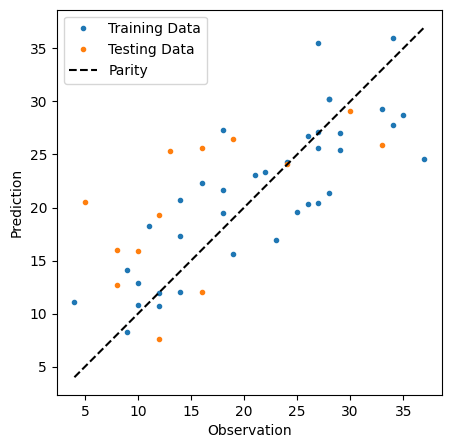

In [9]:
plot_model(model, xtrain, xtest, ytrain, ytest)

Train R² lands well above test R² here -- with only 50 rows and 7 features (plus the
lockstep pair just found), this dataset is exactly the small-sample case Lecture 20
warned about: *one* 75/25 split is a single roll of the dice, and a small dataset makes
that roll noisier. This is not a healthy-and-boring result to wave past -- it's Lecture
20's cross-validation lesson, live: don't trust one split's number on a small dataset:
average several, or read this gap as a sign this model needs more than 50 rows before you
trust its number on a brand-new part.

Don't just take that advice on faith -- try a few more splits and watch the test R² move:

In [10]:
for seed in range(5):
    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(data.index)
    n_test = int(np.ceil(0.25 * len(shuffled)))
    idx_te, idx_tr = shuffled[:n_test], shuffled[n_test:]
    m = fit_linear(x.loc[idx_tr], y.loc[idx_tr])
    resid = m.predict(x.loc[idx_te]) - y.loc[idx_te]
    r2_te = 1 - np.sum(resid ** 2) / np.sum((y.loc[idx_te] - y.loc[idx_te].mean()) ** 2)
    print(f'seed {seed}: test R2 = {r2_te:.3f}')

seed 0: test R2 = 0.094
seed 1: test R2 = 0.454
seed 2: test R2 = 0.192
seed 3: test R2 = 0.539
seed 4: test R2 = 0.213


Five seeds, five noticeably different test R² values -- seed 0's 0.094 above is one of the
unluckier draws, not a verdict on the model, which is exactly why Lecture 20 says to
average several splits before trusting a single number.

## [Check your understanding]

Refit `x_scaled` using only the four features whose standardized coefficients were
largest in Section 4 (`nozzle_temperature`, `infill_density`, `layer_height`,
`wall_thickness`) -- drop `bed_temperature`, `print_velocity`, and `fan_speed` entirely.
Report the new R². Did dropping three small-coefficient features cost much of the R² from
the full seven-feature model? What does your answer say about whether those three
features were pulling their weight?

# The industrial one-liner: scikit-learn (a look ahead, not exam material)

Outside this course -- in research groups, internships, and every tutorial on the internet --
multivariate fits are usually done with the `scikit-learn` library. It is the same least-squares
math you just ran through `np.linalg.lstsq`, wrapped in an object (Lecture 15's pattern):

In [11]:
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression().fit(x, y)
print(f'scikit-learn R^2: {sk_model.score(x, y):.4f}   (lstsq gave the same 0.6368)')
print(f'bed_temperature coefficient: {sk_model.coef_[4]:.3f}   (lstsq said 1.135)')
print(f'fan_speed coefficient:       {sk_model.coef_[6]:.3f}   (lstsq said -0.211)')

scikit-learn R^2: 0.6368   (lstsq gave the same 0.6368)
bed_temperature coefficient: 0.003   (lstsq said 1.135)
fan_speed coefficient:       0.015   (lstsq said -0.211)


Identical R-squared, identical predictions (to 12 decimal places) -- and *different* coefficients
for exactly one pair: `bed_temperature`/`fan_speed`, the locked-together columns from the aside
above. Two correct solvers, two different ways of splitting credit between features the data
never varied independently -- live proof of that aside, from an independent tool. You will not
need scikit-learn on any exam or homework in this course; MATSE 419 uses it daily, and when you
meet it there, remember it is running the mathematics you already own.

# Wrap-up

* Many features, same line idea: more slopes, one intercept.
* A coefficient means "per-unit effect, holding other features fixed" -- not "how much
  this input matters" on its own.
* Raw coefficient size can mislead when features are on different scales -- standardize
  (`(x - mean) / std`) before comparing importance across features.
* Features that move together in the data (like `bed_temperature`/`fan_speed` here) can't
  have their individual effects separated by fitting alone -- only by a better-designed
  experiment.
* Keep evaluating honestly: train/test, every model, every time -- small datasets make one
  split noisier, not exempt from the habit.

**Take-home message:** a coefficient's size only means what you think it means once every
feature is measured on a comparable scale -- and no amount of clever fitting can separate
the effects of two inputs that were never varied independently.

Next class: Lecture 24 asks how you *look at* a model with two inputs and one output --
meshgrids, contours, and 3D surfaces, using this exact fitted model as the example.
Homework 8 repeats today's pattern on the concrete-strength dataset.